In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings, string
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

In [2]:
df = pd.read_csv('Preprocessed Fake Reviews Detection Dataset.csv')
df.head()

,Unnamed: 0,category,rating,label,text_
0,0,Home_and_Kitchen_5,5.0,CG,love well made sturdi comfort i love veri pretti
1,1,Home_and_Kitchen_5,5.0,CG,love great upgrad origin i 've mine coupl year
2,2,Home_and_Kitchen_5,5.0,CG,thi pillow save back i love look feel pillow
3,3,Home_and_Kitchen_5,1.0,CG,miss inform use great product price i
4,4,Home_and_Kitchen_5,5.0,CG,veri nice set good qualiti we set two month


In [3]:
df.drop('Unnamed: 0',axis=1,inplace=True)

In [4]:
df.head(10)

,category,rating,label,text_
0,Home_and_Kitchen_5,5.0,CG,love well made sturdi comfort i love veri pretti
1,Home_and_Kitchen_5,5.0,CG,love great upgrad origin i 've mine coupl year
2,Home_and_Kitchen_5,5.0,CG,thi pillow save back i love look feel pillow
3,Home_and_Kitchen_5,1.0,CG,miss inform use great product price i
4,Home_and_Kitchen_5,5.0,CG,veri nice set good qualiti we set two month
5,Home_and_Kitchen_5,3.0,CG,i want differ flavor but they are not
6,Home_and_Kitchen_5,5.0,CG,they perfect touch thing i wish littl space
7,Home_and_Kitchen_5,3.0,CG,these done fit well look great i love smooth e...
8,Home_and_Kitchen_5,5.0,CG,great big number easi read thing i n't like size
9,Home_and_Kitchen_5,5.0,CG,my son love comfort well made we also babi


In [5]:
df.dropna(inplace=True)

In [6]:
df['length'] = df['text_'].apply(len)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 40431 entries, 0 to 40431
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   category  40431 non-null  object 
 1   rating    40431 non-null  float64
 2   label     40431 non-null  object 
 3   text_     40431 non-null  object 
 4   length    40431 non-null  int64  
dtypes: float64(1), int64(1), object(3)
memory usage: 1.9+ MB


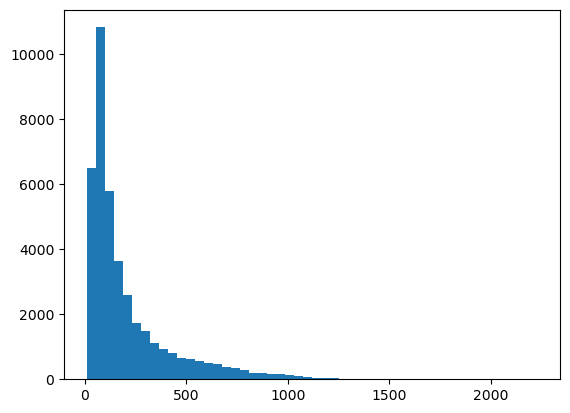

In [8]:
plt.hist(df['length'],bins=50)
plt.show()

In [9]:
df.groupby('label').describe()

rating                                                length  \
         count      mean       std  min  25%  50%  75%  max    count   
label                                                                  
CG     20215.0  4.259906  1.141092  1.0  4.0  5.0  5.0  5.0  20215.0   
OR     20216.0  4.253265  1.147652  1.0  4.0  5.0  5.0  5.0  20216.0   

                                                                 
             mean         std   min   25%    50%    75%     max  
label                                                            
CG     173.639030  173.955252  13.0  57.0   99.0  217.0  1300.0  
OR     237.892758  252.920635   8.0  74.0  134.0  296.0  2232.0

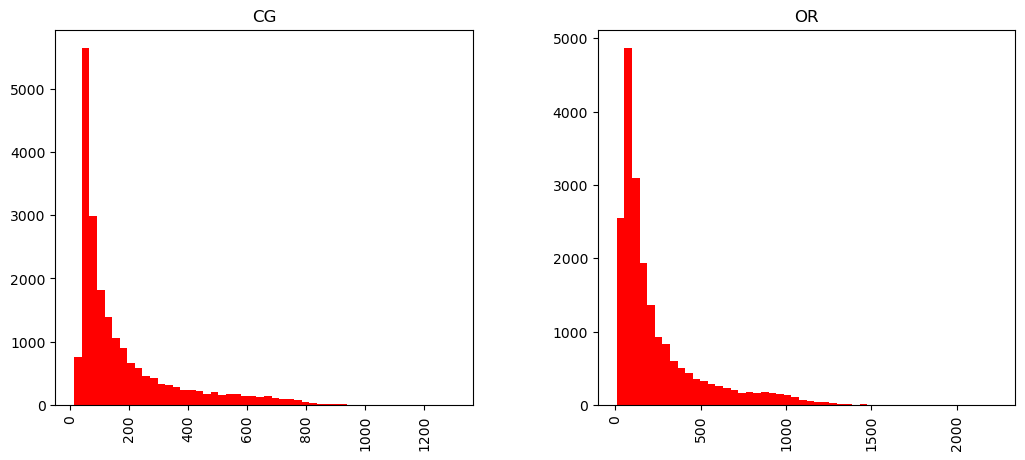

In [10]:
df.hist(column='length',by='label',bins=50,color='red',figsize=(12,5))
plt.show()

In [11]:
df[df['label']=='OR'][['text_','length']].sort_values(by='length',ascending=False).head().iloc[0].text_

"weak on current scienc after see twice i agre much posit five star review out respect read review i 'll repeat everyth i like present i found goofi over ear hairdo facial hair arrang daniel vitali describ `` wild food expert '' distract ugh ditto david wolf extrem goofi wild hairdo on hand jon gabriel describ `` author weight loss expert '' nice groom good present hi stori person transform fellow pound whew becom jock normal weight inspir christian northrup preserv rank one america 's cutest doctor a realli nice look woman present dr. mercola jason vale kri carr alejandro junger fine it disappoint jami oliv popular uk give babi cow growth fluid pas unscientif popular idea milk none present anyth zilch say work doctor t. colin campbel milk bodi bad it good see present take stand sugar they agre evil sugar refin carbohydr with respect dr. northrup `` it 's fat make fat 's sugar '' statement pas muster commun expert recogn evil sugar not mutual exclus recogn proven danger fat particularl

In [12]:
df.length.describe()

count    40431.000000
mean       205.766689
std        219.422084
min          8.000000
25%         64.000000
50%        116.000000
75%        253.000000
max       2232.000000
Name: length, dtype: float64

In [13]:
def text_process(review):
    nopunc = [char for char in review if char not in string.punctuation]
    nopunc = ''.join(nopunc)
    return [word for word in nopunc.split() if word.lower() not in stopwords.words('english')]

In [14]:
bow_transformer = CountVectorizer(analyzer=text_process)
bow_transformer

,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (strip_accents and lowercase) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None
,"stop_words stop_words: {'english'}, list, default=NoneIf 'english', a built-in stop word list for English is used.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",None
,"token_pattern token_pattern: str or None, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp select tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'(?u)\\b\\w\\w+\\b'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentword n-grams or char n-grams to be extracted. All values of n suchsuch that min_n <= n <= max_n will be used. For example an``ngram_range`` of ``(1, 1)`` means only unigrams, ``(1, 2)`` meansunigrams and bigrams, and ``(2, 2)`` means only bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word n-gram or charactern-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21Since v0.21, if ``input`` is ``filename`` or ``file``, the data isfirst read from the file and then passed to the given callableanalyzer.",<function tex...00267239E9620>


In [15]:
review4 = df['text_'][3]
review4

'miss inform use great product price i'

In [18]:
from sklearn.feature_extraction.text import CountVectorizer
import re
import string

# Faster preprocessing function
def fast_text_process(text):
    # remove punctuation
    text = re.sub(f"[{string.punctuation}]", " ", text)
    
    # lowercase and split
    words = text.lower().split()
    
    return words


# Initialize vectorizer
bow_transformer = CountVectorizer(analyzer=fast_text_process)

# Fit on the text column
bow_transformer.fit(df['text_'])

# Vocabulary size
print("Total Vocabulary:", len(bow_transformer.vocabulary_))

# Transform the 4th review
review4 = df['text_'].iloc[3]
print("Review 4:", review4)

bow_msg4 = bow_transformer.transform([review4])

# Print sparse matrix
print(bow_msg4)
print("Shape:", bow_msg4.shape)
print("Number of unique words in review 4:", bow_msg4.nnz)

# Access feature names
feature_names = bow_transformer.get_feature_names_out()

# Safe indexing
if len(feature_names) > 15841:
    print("Word at index 15841:", feature_names[15841])

if len(feature_names) > 23848:
    print("Word at index 23848:", feature_names[23848])

# Transform the entire corpus
bow_reviews = bow_transformer.transform(df['text_'])

print("Shape of Bag of Words for entire corpus:", bow_reviews.shape)
print("Number of non-zero values in BoW matrix:", bow_reviews.nnz)

Total Vocabulary: 29513
Review 4: miss inform use great product price i
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 7 stored elements and shape (1, 29513)>
  Coords	Values
  (0, 11817)	1
  (0, 13267)	1
  (0, 13650)	1
  (0, 17150)	1
  (0, 20462)	1
  (0, 20567)	1
  (0, 27691)	1
Shape: (1, 29513)
Number of unique words in review 4: 7
Word at index 15841: lori
Word at index 23848: skunk
Shape of Bag of Words for entire corpus: (40431, 29513)
Number of non-zero values in BoW matrix: 1155715


In [20]:
sparsity = bow_reviews.nnz / (bow_reviews.shape[0] * bow_reviews.shape[1])
print(f"Sparsity: {sparsity*100:.2f}%")

Sparsity: 0.10%


In [21]:
#Couting most freq words
word_counts = np.array(bow_reviews.sum(axis=0)).flatten()
feature_names = bow_transformer.get_feature_names_out()
word_freq = list(zip(feature_names, word_counts))
word_freq_sorted = sorted(word_freq, key=lambda x: x[1], reverse=True)
print("Top 20 most frequent words:\n")
for word, count in word_freq_sorted[:20]:
    print(word, ":", count)

Top 20 most frequent words:

i : 111117
the : 32014
s : 19881
love : 19103
it : 17723
book : 17677
great : 17272
t : 15275
n : 15073
one : 15061
good : 14426
thi : 12792
like : 12761
use : 12662
read : 11902
well : 10904
would : 10780
stori : 10339
work : 8648
get : 8378


In [23]:
#Converting label to number 
df['label'] = df['label'].map({'CG':1, 'OR':0}) #Computer generated (fake)-> 1 and Original review-> 0

In [24]:
df['label'].value_counts()

0    20216
1    20215
Name: label, dtype: int64

In [27]:
tfidf_transformer = TfidfTransformer().fit(bow_reviews)
tfidf_rev4 = tfidf_transformer.transform(bow_msg4)
print(bow_msg4) #This is the Bag-of-Words representation of the 4th review.

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 7 stored elements and shape (1, 29513)>
  Coords	Values
  (0, 11817)	1
  (0, 13267)	1
  (0, 13650)	1
  (0, 17150)	1
  (0, 20462)	1
  (0, 20567)	1
  (0, 27691)	1


In [28]:
print("Bag of Words:")
print(bow_msg4)

print("\nTF-IDF:")
print(tfidf_rev4)

Bag of Words:
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 7 stored elements and shape (1, 29513)>
  Coords	Values
  (0, 11817)	1
  (0, 13267)	1
  (0, 13650)	1
  (0, 17150)	1
  (0, 20462)	1
  (0, 20567)	1
  (0, 27691)	1

TF-IDF:
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 7 stored elements and shape (1, 29513)>
  Coords	Values
  (0, 11817)	0.2258182930215873
  (0, 13267)	0.13592166439905207
  (0, 13650)	0.5589769572183708
  (0, 17150)	0.5568439973876792
  (0, 20462)	0.3561644555389282
  (0, 20567)	0.33482219290541343
  (0, 27691)	0.26275826020256515


In [34]:
#used to show how TF-IDF values work.

'''word → find its index in vocabulary
         ↓
use that index → get IDF value from tfidf_transformer'''
print(tfidf_transformer.idf_[bow_transformer.vocabulary_['wrist']])
print(tfidf_transformer.idf_[bow_transformer.vocabulary_['book']])
#Rare words → high IDF
#Common words → low IDF

7.012256979493386
2.819393433430175


In [36]:
idf_values = pd.DataFrame({
    'word': bow_transformer.get_feature_names_out(),
    'idf': tfidf_transformer.idf_
})
idf_values.sort_values(by='idf', ascending=False).tail(20)

,word,idf
21322,read,2.923145
15675,littl,2.882194
11353,get,2.848650
28986,work,2.839269
4156,book,2.819393
28518,well,2.685786
29041,would,2.672526
27691,use,2.618057
15558,like,2.562029
11620,good,2.447173


In [37]:
#size and structure of the TF-IDF matrix after transformation.
tfidf_reviews = tfidf_transformer.transform(bow_reviews)
print("Shape:",tfidf_reviews.shape)
print("No. of Dimensions:",tfidf_reviews.ndim)
#reviews × vocabulary

Shape: (40431, 29513)
No. of Dimensions: 2


In [39]:
print("Non-zero values:", tfidf_reviews.nnz)

Non-zero values: 1155715


### Now, Creating training and testing data

In [40]:
review_train, review_test, label_train, label_test = train_test_split(
    df['text_'], df['label'], test_size=0.20, random_state=42
)

In [43]:
pipeline = Pipeline([
    ('bow',CountVectorizer(stop_words='english')),
    ('tfidf',TfidfTransformer()),
    ('classifier',MultinomialNB())
])

### Training and testing Multinomial Naive Bayes Algorithm on the preprocessed data

In [44]:
pipeline.fit(review_train,label_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('bow', ...), ('tfidf', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (strip_accents and lowercase) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [45]:
predictions = pipeline.predict(review_test)
predictions

array([1, 1, 0, ..., 1, 0, 0], dtype=int64)

In [46]:
print('Classification Report:',classification_report(label_test,predictions))
print('---------------------------------------------')
print('Confusion Matrix:',confusion_matrix(label_test,predictions))
print('---------------------------------------------')
print('Accuracy Score:',accuracy_score(label_test,predictions))

Classification Report:               precision    recall  f1-score   support

           0       0.87      0.79      0.83      4069
           1       0.80      0.88      0.84      4018

    accuracy                           0.83      8087
   macro avg       0.84      0.83      0.83      8087
weighted avg       0.84      0.83      0.83      8087

---------------------------------------------
Confusion Matrix: [[3203  866]
 [ 471 3547]]
---------------------------------------------
Accuracy Score: 0.8346729318659577


In [47]:
print('Model Prediction Accuracy:',str(np.round(accuracy_score(label_test,predictions)*100,2)) + '%')

Model Prediction Accuracy: 83.47%


In [51]:
from xgboost import XGBClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier()
}

In [52]:
results = {}

for name, model in models.items():

    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(stop_words='english')),
        ('classifier', model)
    ])

    pipeline.fit(review_train, label_train)

    predictions = pipeline.predict(review_test)

    acc = accuracy_score(label_test, predictions)

    results[name] = acc

    print("Model:", name)
    print("Accuracy:", acc)
    print(classification_report(label_test, predictions))
    print("-"*50)

Model: Naive Bayes
Accuracy: 0.8346729318659577
              precision    recall  f1-score   support

           0       0.87      0.79      0.83      4069
           1       0.80      0.88      0.84      4018

    accuracy                           0.83      8087
   macro avg       0.84      0.83      0.83      8087
weighted avg       0.84      0.83      0.83      8087

--------------------------------------------------
Model: Logistic Regression
Accuracy: 0.8527265982440955
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      4069
           1       0.87      0.83      0.85      4018

    accuracy                           0.85      8087
   macro avg       0.85      0.85      0.85      8087
weighted avg       0.85      0.85      0.85      8087

--------------------------------------------------
Model: Random Forest
Accuracy: 0.8467911462841597
              precision    recall  f1-score   support

           0       0.87      0.82  

In [55]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english', ngram_range=(1,2),max_features=20000,
        min_df=5)),
    ('classifier', LogisticRegression(max_iter=1000))
])

scores = cross_val_score(pipeline, df['text_'], df['label'], cv=5)

print("CV Scores:", scores)
print("Average CV Accuracy:", scores.mean())

CV Scores: [0.86830716 0.77764037 0.81412318 0.85258471 0.81239179]
Average CV Accuracy: 0.8250094408320644


In [58]:
pipeline.fit(review_train,label_train)

pred = pipeline.predict(review_test)

from sklearn.metrics import classification_report,accuracy_score

print("Accuracy:",accuracy_score(label_test,pred))
print(classification_report(label_test,pred))

Accuracy: 0.886608136515395
              precision    recall  f1-score   support

           0       0.88      0.90      0.89      4069
           1       0.90      0.87      0.88      4018

    accuracy                           0.89      8087
   macro avg       0.89      0.89      0.89      8087
weighted avg       0.89      0.89      0.89      8087



In [59]:
#Linear SVM
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_val_score

pipeline_svm = Pipeline([
 ('tfidf', TfidfVectorizer(
        stop_words='english',
        ngram_range=(1,2),
        max_features=20000,
        min_df=5
 )),
 ('classifier', LinearSVC())
])

scores = cross_val_score(pipeline_svm, df['text_'], df['label'], cv=5)

print("SVM CV Accuracy:", scores.mean())

SVM CV Accuracy: 0.8283485148723193


In [60]:
final_pipeline = Pipeline([
 ('tfidf', TfidfVectorizer(
        stop_words='english',
        ngram_range=(1,2),
        max_features=20000,
        min_df=5
 )),
 ('classifier', LogisticRegression(C=5, max_iter=1000))
])

final_pipeline.fit(review_train, label_train)

pred = final_pipeline.predict(review_test)

from sklearn.metrics import accuracy_score, classification_report

print("Final Accuracy:", accuracy_score(label_test, pred))
print(classification_report(label_test, pred))

Final Accuracy: 0.8973661431927785
              precision    recall  f1-score   support

           0       0.89      0.91      0.90      4069
           1       0.90      0.89      0.90      4018

    accuracy                           0.90      8087
   macro avg       0.90      0.90      0.90      8087
weighted avg       0.90      0.90      0.90      8087



In [61]:
import pickle

pickle.dump(final_pipeline, open("fake_review_model.pkl", "wb"))

In [62]:
review = ["This product is amazing highly recommended"]

prediction = final_pipeline.predict(review)

print("Prediction:", prediction)

Prediction: [1]


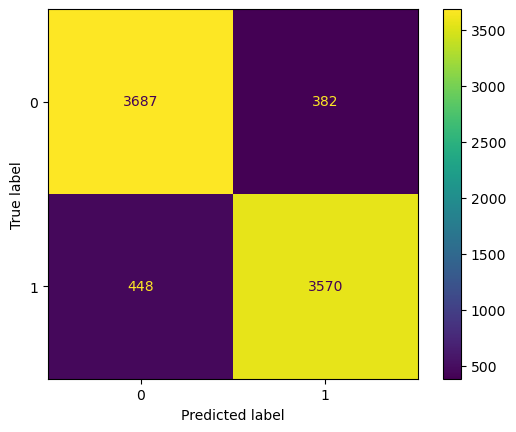

In [63]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(final_pipeline, review_test, label_test)

In [65]:
print("Final Accuracy: {:.2f}%".format(accuracy_score(label_test, pred) * 100))

Final Accuracy: 89.74%


In [66]:
!pip install streamlit scikit-learn pandas numpy joblib

In [67]:
import os
os.getcwd()

'C:\\Users\\kirti\\Fake News Detection'